# Punto 1 · Notebook 01 – Exploración de la serie, preparación y modelo recurrente

**Taller 1 – Aprendizaje Profundo** · Daniel Sebastian Velasco Munar

En el notebook anterior (`00`) bajamos los datos de MeteoNet, revisamos la calidad de todas las estaciones de la zona NW y nos quedamos con la **estación 62548002** (cerca de Calais, en la costa norte de Francia, a 3 m sobre el nivel del mar). De ahí salió un CSV horario con 3 años de datos (2016-2018) que es lo que usamos acá.

Este notebook tiene todo el desarrollo del Punto 1, en orden:

1. **Entender la serie** antes de modelar (secciones 1-4): cómo se comporta la temperatura, qué tan fuertes son los ciclos diario y anual, dónde hay huecos, y qué relación tiene con las otras variables. Esto nos sirve para tomar decisiones con argumentos y no a ojo.
2. **Definir la tarea de predicción** (sección 5): cuántas horas hacia atrás mira el modelo y cuántas hacia adelante predice. El taller pide dejar esto explícito.
3. **Preparar los datos** (secciones 6-7): imputar los pocos faltantes, construir las variables de calendario, partir en entrenamiento / validación / test **sin fuga de información**.
4. **Modelar con redes recurrentes** (secciones 8-11): líneas base, comparación SimpleRNN / LSTM / GRU, búsqueda de hiperparámetros con validación, y evaluación final en el 30 % de test con análisis de errores.

Las secciones 1-7 corren en cualquier máquina; de la 8 en adelante conviene **GPU** (en Colab: *Entorno de ejecución > Cambiar tipo de entorno > T4*).


## 0. Preparación del entorno

In [1]:
import os, sys, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

EN_COLAB = "google.colab" in sys.modules
print("Colab:", EN_COLAB)


Colab: True


In [2]:
# En Colab clonamos el repo para leer el CSV de la estación y dejar las figuras en results/.
REPO_URL = "https://github.com/DANIEL-VELASCO/taller1-deep-learning.git"

if EN_COLAB:
    if not Path("/content/taller1-deep-learning").exists():
        !git clone -q {REPO_URL} /content/taller1-deep-learning
    RAIZ = Path("/content/taller1-deep-learning")
else:
    RAIZ = Path.cwd().resolve().parents[1]     # el notebook vive en code/punto1_rnn_meteonet/

ESTACION = 62548002
RUTA_DATA = RAIZ / "code" / "punto1_rnn_meteonet" / "data"
RUTA_RES = RAIZ / "results" / "punto1"
RUTA_RES.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(RUTA_DATA / f"estacion_{ESTACION}_horaria.csv", index_col="date", parse_dates=True)
with open(RUTA_DATA / f"estacion_{ESTACION}_metadatos.json", encoding="utf-8") as f:
    meta = json.load(f)

print(f"{len(df):,} filas  |  {df.index.min()}  ->  {df.index.max()}")
meta


26,304 filas  |  2016-01-01 00:00:00  ->  2018-12-31 23:00:00


{'zona': 'NW',
 'estacion': 62548002,
 'anios': [2016, 2017, 2018],
 'lat': 50.96,
 'lon': 1.96,
 'height_sta': 3.0,
 'frecuencia': '1h',
 'n_filas': 26304,
 'pct_nan_t_c': 0.0009124087591240876,
 'columnas': ['t_c',
  'td_c',
  'hu',
  'psl_hpa',
  'ff',
  'u',
  'v',
  'precip',
  'n_obs']}

## 1. Primer vistazo

Recordatorio de qué es cada columna (ya vienen convertidas a unidades "normales" desde el notebook `00`):

- `t_c`: temperatura (°C). **Es lo que queremos predecir.**
- `td_c`: punto de rocío (°C). Muy ligado a la humedad.
- `hu`: humedad relativa (%).
- `psl_hpa`: presión a nivel del mar (hPa).
- `ff`: velocidad del viento (m/s); `u`, `v`: el mismo viento en componentes este-oeste y norte-sur, para que la dirección no tenga el salto de 359°→0°.
- `precip`: lluvia acumulada en la hora (mm).
- `n_obs`: cuántas observaciones de 6 min había en esa hora (máximo 10). Solo para control de calidad, no entra al modelo.


In [3]:
display(df.head())
df.describe().T.round(2)


,t_c,td_c,hu,psl_hpa,ff,u,v,precip,n_obs
date,,,,,,,,,
2016-01-01 00:00:00,6.74,3.72,81.3,1021.57,3.97,3.511,1.417,0.0,10
2016-01-01 01:00:00,6.23,3.13,80.6,1022.54,3.55,3.516,0.093,0.0,10
2016-01-01 02:00:00,5.30,2.80,83.9,1023.31,2.19,2.096,0.103,0.0,10
2016-01-01 03:00:00,4.09,2.41,88.9,1023.68,2.14,1.620,1.048,0.0,10
2016-01-01 04:00:00,3.10,1.78,91.1,1023.86,1.81,1.172,1.315,0.0,10


,count,mean,std,min,25%,50%,75%,max
t_c,26280.0,11.45,6.00,-7.63,7.11,11.24,15.96,33.26
td_c,26280.0,8.05,5.39,-15.08,4.19,8.40,12.40,20.21
hu,26280.0,80.90,12.81,24.60,72.70,83.40,91.10,100.00
psl_hpa,26280.0,1016.35,9.86,971.56,1010.89,1017.38,1022.94,1046.11
ff,26279.0,4.83,2.87,0.00,2.59,4.33,6.69,20.40
u,26279.0,1.45,4.00,-13.68,-1.32,1.08,4.19,17.13
v,26279.0,0.51,3.59,-15.54,-1.82,0.99,2.89,15.63
precip,26278.0,0.08,0.48,0.00,0.00,0.00,0.00,21.90
n_obs,26304.0,9.98,0.35,0.00,10.00,10.00,10.00,10.00


Algo que vale la pena revisar de una: la columna `n_obs`. Si casi siempre es 10, el promedio horario está bien soportado. Si hay muchas horas con 1 o 2 observaciones, esos promedios son ruidosos.

In [4]:
print(df["n_obs"].value_counts().sort_index())
print(f"\nHoras con las 10 observaciones completas: {(df['n_obs']==10).mean():.1%}")


n_obs
0        24
1         2
2         2
3         5
4         1
5         4
6         4
7         6
8        22
9        40
10    26194
Name: count, dtype: int64

Horas con las 10 observaciones completas: 99.6%


## 2. Valores faltantes

En el `00` vimos que a esta estación le falta el 0.09% de la temperatura a nivel horario. Es muy poco, pero hay que saber **cómo** falta: no es lo mismo 24 horas sueltas repartidas en 3 años que un día completo sin datos. Lo primero se rellena sin problema interpolando; lo segundo no se puede inventar.

In [5]:
faltantes = df.isna().mean().sort_values(ascending=False)
print((faltantes * 100).round(3).astype(str) + " %")

# Longitud de los huecos consecutivos en la temperatura
falta_t = df["t_c"].isna()
id_hueco = (~falta_t).cumsum()[falta_t]
huecos = falta_t[falta_t].groupby(id_hueco).agg(["size"])
huecos["inicio"] = falta_t[falta_t].groupby(id_hueco).apply(lambda s: s.index.min())
huecos = huecos.rename(columns={"size": "horas"}).sort_values("horas", ascending=False).reset_index(drop=True)
print(f"\n{len(huecos)} huecos en la temperatura. Los más largos:")
huecos.head(10)


precip     0.099 %
u          0.095 %
ff         0.095 %
v          0.095 %
t_c        0.091 %
psl_hpa    0.091 %
hu         0.091 %
td_c       0.091 %
n_obs        0.0 %
dtype: object

6 huecos en la temperatura. Los más largos:


,horas,inicio
0,9,2018-01-21 23:00:00
1,4,2016-05-15 04:00:00
2,4,2016-05-19 09:00:00
3,3,2016-05-24 04:00:00
4,3,2016-05-24 10:00:00
5,1,2016-05-22 11:00:00


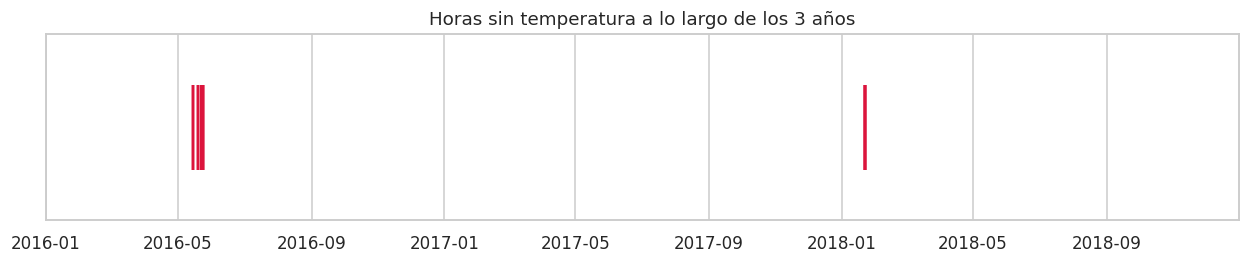

In [6]:
fig, ax = plt.subplots(figsize=(14, 2.2))
ax.eventplot(df.index[df["t_c"].isna()].values, colors="crimson", linelengths=0.8)
ax.set_yticks([]); ax.set_title("Horas sin temperatura a lo largo de los 3 años")
ax.set_xlim(df.index.min(), df.index.max())
fig.savefig(RUTA_RES / "eda_huecos_temperatura.png", bbox_inches="tight"); plt.show()


> **Observaciones:** en 3 años solo hay **6 huecos** de temperatura, 24 horas en total. Cinco están concentrados en mayo de 2016 (dos de 4 h, dos de 3 h y uno de 1 h) y el más largo, de **9 h**, es del 21-22 de enero de 2018, que cae dentro del conjunto de validación. No hay ningún periodo largo sin datos ni un patrón que sugiera un sensor dañado. Con esto la estrategia es clara: los huecos cortos se interpolan sin miedo (son unas pocas horas dentro de días normales) y el de 9 h se deja vacío, porque interpolar una noche casi completa sería inventarse el ciclo diario.

## 3. Cómo se comporta la temperatura

Primero la serie completa. Lo que esperamos ver: el ciclo anual (veranos e inviernos) y, por ser una estación costera, una amplitud relativamente moderada (el mar amortigua los extremos).

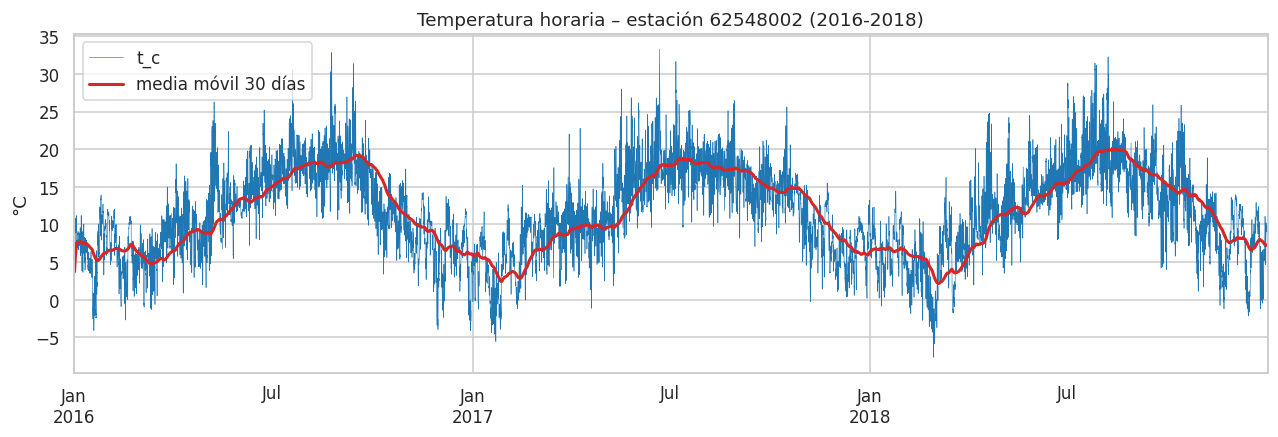

In [7]:
fig, ax = plt.subplots(figsize=(14, 4))
df["t_c"].plot(ax=ax, lw=0.4, color="tab:blue")
df["t_c"].rolling("30D").mean().plot(ax=ax, lw=2, color="tab:red", label="media móvil 30 días")
ax.set_ylabel("°C"); ax.set_xlabel(""); ax.legend(loc="upper left")
ax.set_title(f"Temperatura horaria – estación {ESTACION} (2016-2018)")
fig.savefig(RUTA_RES / "eda_serie_completa.png", bbox_inches="tight"); plt.show()


Ahora un zoom de dos semanas, para ver el ciclo diario "de cerca". Ojo con qué tan regular es: si cada día se ve parecido al anterior, el modelo lo va a tener relativamente fácil; si hay días donde el patrón se rompe (frentes, lluvia), ahí es donde va a fallar.

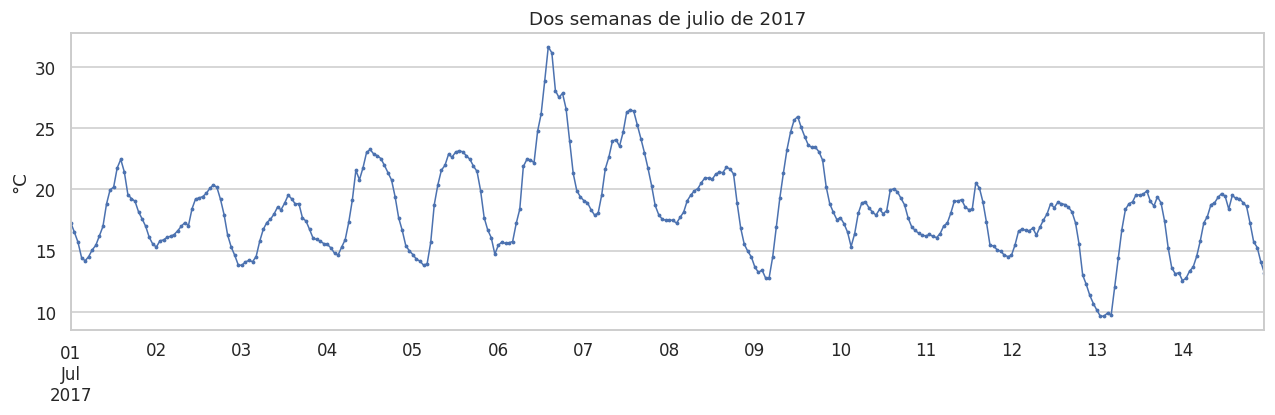

In [8]:
zoom = df.loc["2017-07-01":"2017-07-14", "t_c"]
fig, ax = plt.subplots(figsize=(14, 3.5))
zoom.plot(ax=ax, marker=".", ms=3, lw=1)
ax.set_ylabel("°C"); ax.set_xlabel(""); ax.set_title("Dos semanas de julio de 2017")
fig.savefig(RUTA_RES / "eda_zoom_dos_semanas.png", bbox_inches="tight"); plt.show()


### 3.1 Ciclo anual y ciclo diario

Los dos ciclos que dominan una serie de temperatura. El **anual** se ve agrupando por mes; el **diario** agrupando por hora del día. Y como el ciclo diario cambia con la estación (en verano la amplitud día-noche es mayor), lo dibujamos separado por estación del año.

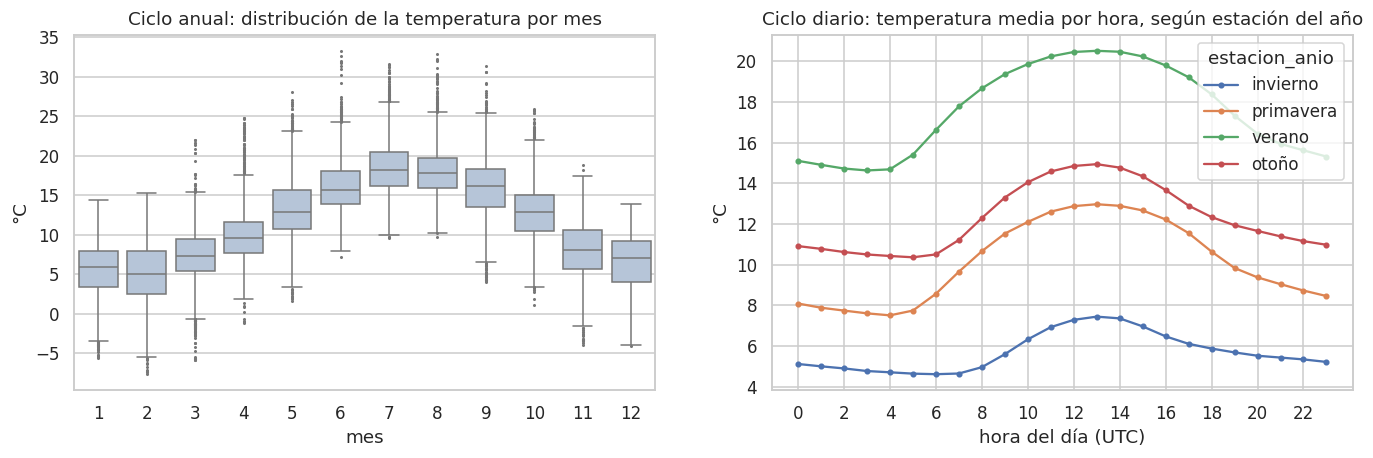

Amplitud del ciclo diario (°C):
estacion_anio
invierno     2.83
primavera    5.47
verano       5.89
otoño        4.58
dtype: float64


In [9]:
df["mes"] = df.index.month
df["hora"] = df.index.hour
estaciones_anio = {12: "invierno", 1: "invierno", 2: "invierno", 3: "primavera", 4: "primavera", 5: "primavera",
                   6: "verano", 7: "verano", 8: "verano", 9: "otoño", 10: "otoño", 11: "otoño"}
df["estacion_anio"] = df["mes"].map(estaciones_anio)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.2))

sns.boxplot(data=df, x="mes", y="t_c", ax=axes[0], color="lightsteelblue", fliersize=1)
axes[0].set_title("Ciclo anual: distribución de la temperatura por mes"); axes[0].set_ylabel("°C")

perfil = df.groupby(["estacion_anio", "hora"])["t_c"].mean().unstack(0)[["invierno", "primavera", "verano", "otoño"]]
perfil.plot(ax=axes[1], marker="o", ms=3)
axes[1].set_title("Ciclo diario: temperatura media por hora, según estación del año")
axes[1].set_xlabel("hora del día (UTC)"); axes[1].set_ylabel("°C"); axes[1].set_xticks(range(0, 24, 2))

fig.savefig(RUTA_RES / "eda_ciclos_anual_diario.png", bbox_inches="tight"); plt.show()

amplitud = perfil.max() - perfil.min()
print("Amplitud del ciclo diario (°C):"); print(amplitud.round(2))


> **Observaciones:** la amplitud del ciclo diario va de **2,8 °C en invierno a 5,9 °C en verano** (5,5 en primavera, 4,6 en otoño). El pico se da hacia las 13-14 UTC y el mínimo hacia las 4-6 UTC, con la forma asimétrica típica: sube rápido en la mañana y baja lento en la tarde-noche. El ciclo anual es mucho mayor: la mediana mensual va de ~5 °C en enero-febrero a ~18 °C en julio-agosto, unos 13 °C de rango. Se nota el efecto costero: pocos extremos (mínimo -7,6 °C, máximo 33,3 °C en 3 años) y una amplitud diaria moderada. Para la tarea esto quiere decir que predecir a 24 h exige reproducir un ciclo de 3 a 6 °C de amplitud según la época, mientras que a 1 h el cambio típico es de medio grado.

### 3.2 Distribución

Miramos el histograma por dos razones: ver si hay valores absurdos (un sensor dañado se nota como picos raros) y saber si la variable es más o menos simétrica, que es lo que le gusta a una red con `StandardScaler`.

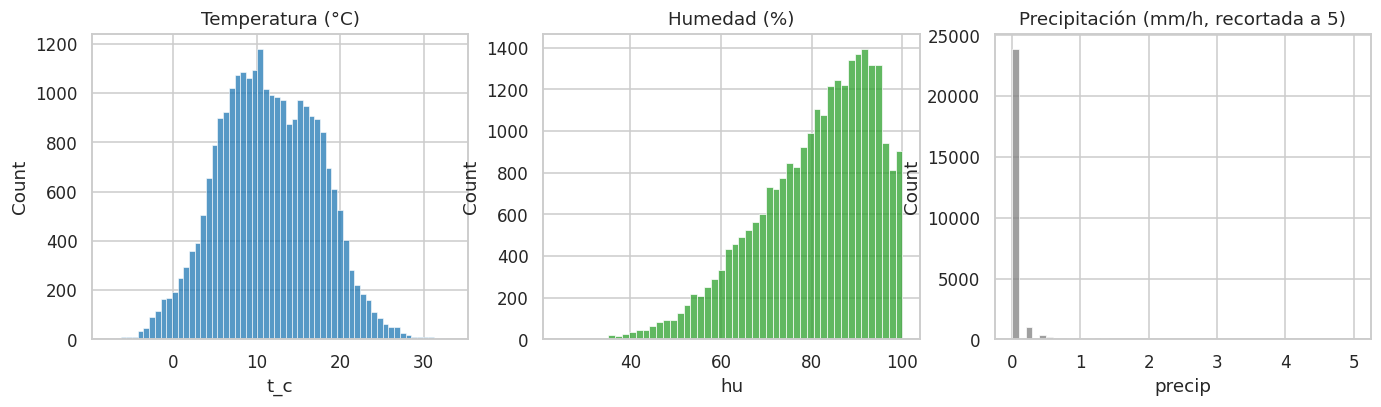

Horas con lluvia > 0: 9.1%


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
sns.histplot(df["t_c"].dropna(), bins=60, ax=axes[0], color="tab:blue"); axes[0].set_title("Temperatura (°C)")
sns.histplot(df["hu"].dropna(), bins=50, ax=axes[1], color="tab:green"); axes[1].set_title("Humedad (%)")
sns.histplot(df["precip"].dropna().clip(upper=5), bins=50, ax=axes[2], color="tab:gray"); axes[2].set_title("Precipitación (mm/h, recortada a 5)")
fig.savefig(RUTA_RES / "eda_distribuciones.png", bbox_inches="tight"); plt.show()

print(f"Horas con lluvia > 0: {(df['precip'] > 0).mean():.1%}")


## 4. Relación con las otras variables y "memoria" de la serie

Dos preguntas que nos importan para decidir qué entra al modelo y con cuánta historia:

1. ¿Las demás variables aportan información sobre la temperatura? (correlación)
2. ¿Cuánto "se acuerda" la temperatura de sí misma? (autocorrelación). Esto es lo que justifica la **longitud de la ventana de entrada**.

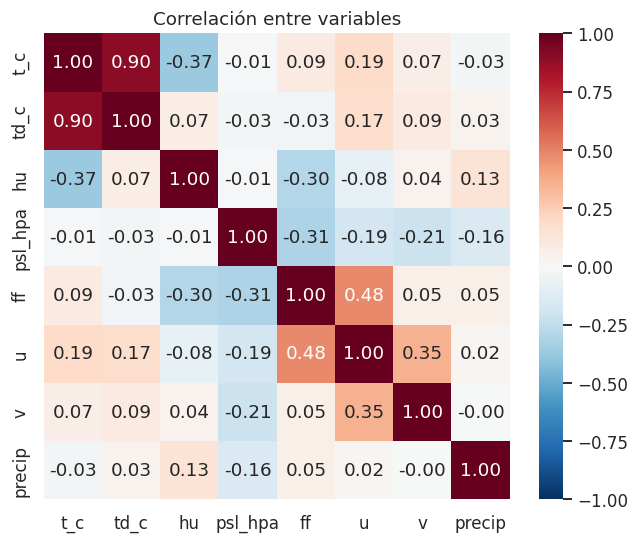

In [11]:
variables = ["t_c", "td_c", "hu", "psl_hpa", "ff", "u", "v", "precip"]
corr = df[variables].corr()

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title("Correlación entre variables")
fig.savefig(RUTA_RES / "eda_correlacion.png", bbox_inches="tight"); plt.show()


La autocorrelación en el rezago *k* mide qué tan parecida es la temperatura de ahora a la de hace *k* horas. En una serie con ciclo diario esperamos picos en 24, 48, 72... horas. Si esos picos se mantienen altos varios días, tiene sentido darle al modelo varios días de historia.

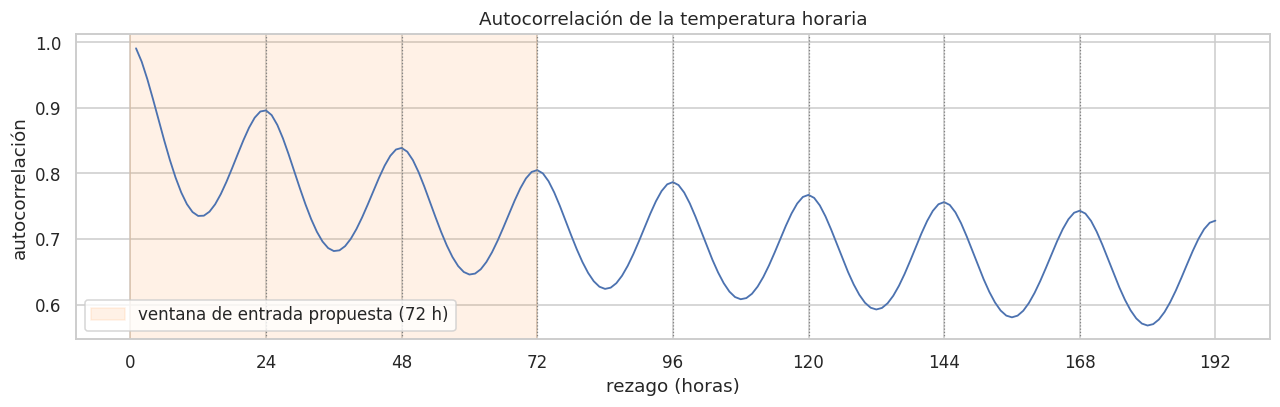

ACF en múltiplos de 24 h: {'24 h': 0.896, '48 h': 0.839, '72 h': 0.805, '96 h': 0.787, '120 h': 0.767, '144 h': 0.756, '168 h': 0.743}


In [12]:
max_lag = 24 * 8
lags = np.arange(1, max_lag + 1)
acf = np.array([df["t_c"].autocorr(lag=k) for k in lags])

fig, ax = plt.subplots(figsize=(14, 3.6))
ax.plot(lags, acf, lw=1.2)
for d in range(1, 8):
    ax.axvline(24 * d, color="gray", ls=":", lw=0.8)
ax.axvspan(0, 72, color="tab:orange", alpha=0.10, label="ventana de entrada propuesta (72 h)")
ax.set_xlabel("rezago (horas)"); ax.set_ylabel("autocorrelación"); ax.set_xticks(range(0, max_lag + 1, 24))
ax.set_title("Autocorrelación de la temperatura horaria"); ax.legend(loc="lower left")
fig.savefig(RUTA_RES / "eda_autocorrelacion.png", bbox_inches="tight"); plt.show()

print("ACF en múltiplos de 24 h:", {f"{24*d} h": round(float(acf[24*d - 1]), 3) for d in range(1, 8)})


### 4.1 ¿Qué tan difícil es cada horizonte?

Antes de entrenar nada conviene saber cuánto error comete el modelo más tonto posible, la **persistencia**: "la temperatura dentro de *k* horas será igual a la de ahora". Su error crece con *k* y nos da una vara para medir a la RNN. Si la red no le gana a esto, no sirve.

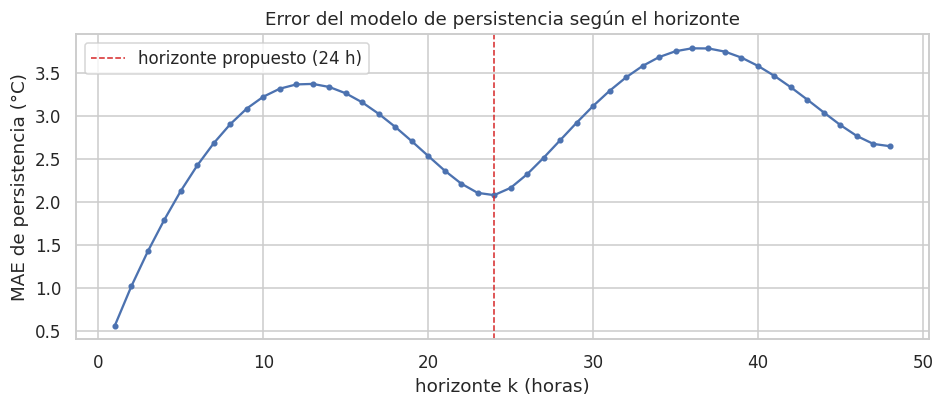

k =  1 h  ->  MAE persistencia = 0.56 °C
k =  3 h  ->  MAE persistencia = 1.43 °C
k =  6 h  ->  MAE persistencia = 2.42 °C
k = 12 h  ->  MAE persistencia = 3.36 °C
k = 24 h  ->  MAE persistencia = 2.08 °C
k = 48 h  ->  MAE persistencia = 2.65 °C


In [13]:
horizontes = np.arange(1, 49)
mae_persistencia = np.array([(df["t_c"].shift(-k) - df["t_c"]).abs().mean() for k in horizontes])

fig, ax = plt.subplots(figsize=(10, 3.6))
ax.plot(horizontes, mae_persistencia, marker="o", ms=3)
ax.axvline(24, color="tab:red", ls="--", lw=1, label="horizonte propuesto (24 h)")
ax.set_xlabel("horizonte k (horas)"); ax.set_ylabel("MAE de persistencia (°C)")
ax.set_title("Error del modelo de persistencia según el horizonte"); ax.legend()
fig.savefig(RUTA_RES / "eda_dificultad_horizonte.png", bbox_inches="tight"); plt.show()

for k in [1, 3, 6, 12, 24, 48]:
    print(f"k = {k:2d} h  ->  MAE persistencia = {mae_persistencia[k-1]:.2f} °C")


> **Observaciones:** el error de persistencia es de **0,56 °C a 1 h**, sube hasta **3,36 °C a 12 h** y vuelve a bajar a **2,08 °C a 24 h**, porque a 24 h se compara la misma hora del día siguiente y el ciclo diario "ayuda". La curva tiene la forma de onda esperada, con otro máximo a 36 h (3,8 °C). Esto confirma dos cosas: que el horizonte de 24 h no es trivial (el promedio del error sobre las 24 horas es alto) y que el modelo de referencia a superar tiene que aprovechar el ciclo diario, no solo el último valor.

## 6. Preparación de los datos

### 6.1 Imputación de faltantes

Regla simple y conservadora: los huecos cortos (hasta 6 horas seguidas) se rellenan con interpolación lineal en el tiempo; los huecos más largos se dejan como `NaN` y más adelante las ventanas que los contienen se descartan. Además marcamos con una bandera qué horas de temperatura fueron imputadas, para poder **excluirlas de las métricas de test**: no tiene sentido evaluar el modelo contra un valor que nos inventamos.

In [14]:
columnas_modelo = ["t_c", "td_c", "hu", "psl_hpa", "ff", "u", "v", "precip"]
LIMITE_INTERP = 6   # horas

original = df[columnas_modelo].copy()
interpolado = original.interpolate(method="time", limit_area="inside")

# Solo aceptamos la interpolación en huecos de hasta LIMITE_INTERP horas seguidas.
# (el parámetro `limit` de pandas no sirve para esto: rellena las primeras N horas de un hueco largo y deja el resto)
def largo_del_hueco(col):
    falta = col.isna()
    ids = (~falta).cumsum()
    return falta.groupby(ids).transform("sum").where(falta, 0)

for col in columnas_modelo:
    rellenar = original[col].isna() & (largo_del_hueco(original[col]) <= LIMITE_INTERP)
    df[col] = original[col].where(~rellenar, interpolado[col])

df["t_imputada"] = original["t_c"].isna() & df["t_c"].notna()

print(f"Horas de temperatura imputadas: {int(df['t_imputada'].sum())}")
print(f"Horas de temperatura que siguen vacías (huecos > {LIMITE_INTERP} h): {int(df['t_c'].isna().sum())}")
print("\nFaltantes restantes por columna:")
print(df[columnas_modelo].isna().sum())


Horas de temperatura imputadas: 15
Horas de temperatura que siguen vacías (huecos > 6 h): 9

Faltantes restantes por columna:
t_c        9
td_c       9
hu         9
psl_hpa    9
ff         9
u          9
v          9
precip     9
dtype: int64


### 6.2 Variables de calendario

Una red no sabe que la hora 23 y la hora 0 son vecinas. Codificar la hora (y el día del año) como seno y coseno resuelve eso: el "reloj" queda como un punto que da vueltas en un círculo, sin saltos.

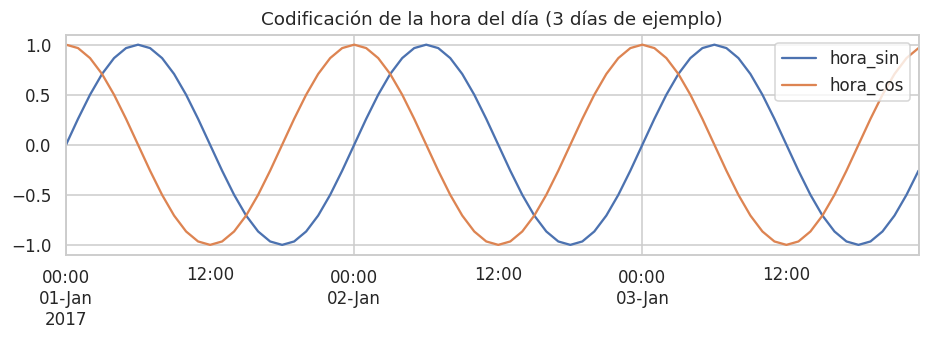

12 variables de entrada: ['t_c', 'td_c', 'hu', 'psl_hpa', 'ff', 'u', 'v', 'precip', 'hora_sin', 'hora_cos', 'dia_sin', 'dia_cos']


In [15]:
horas_dia = 24
dias_anio = 365.25
t_horas = df.index.hour + df.index.minute / 60
dia = df.index.dayofyear + t_horas / 24

df["hora_sin"] = np.sin(2 * np.pi * t_horas / horas_dia)
df["hora_cos"] = np.cos(2 * np.pi * t_horas / horas_dia)
df["dia_sin"] = np.sin(2 * np.pi * dia / dias_anio)
df["dia_cos"] = np.cos(2 * np.pi * dia / dias_anio)

fig, ax = plt.subplots(figsize=(10, 2.6))
df.loc["2017-01-01":"2017-01-03", ["hora_sin", "hora_cos"]].plot(ax=ax)
ax.set_title("Codificación de la hora del día (3 días de ejemplo)"); ax.set_xlabel("")
plt.show()

FEATURES = columnas_modelo + ["hora_sin", "hora_cos", "dia_sin", "dia_cos"]
print(len(FEATURES), "variables de entrada:", FEATURES)


### 6.3 Partición cronológica: entrenamiento / validación / test

Acá está el punto delicado de la rúbrica ("evitando fuga de información"). Cortamos la serie por **fechas**, en orden: lo primero es entrenamiento, luego validación y el 30% final es test. Nada de barajar. Y guardamos los índices de corte en la configuración.

entrenamiento  15,650 h  (59.5%)   2016-01-01 00:00:00  ->  2017-10-14 01:00:00
validacion      2,762 h  (10.5%)   2017-10-14 02:00:00  ->  2018-02-06 03:00:00
test            7,892 h  (30.0%)   2018-02-06 04:00:00  ->  2018-12-31 23:00:00


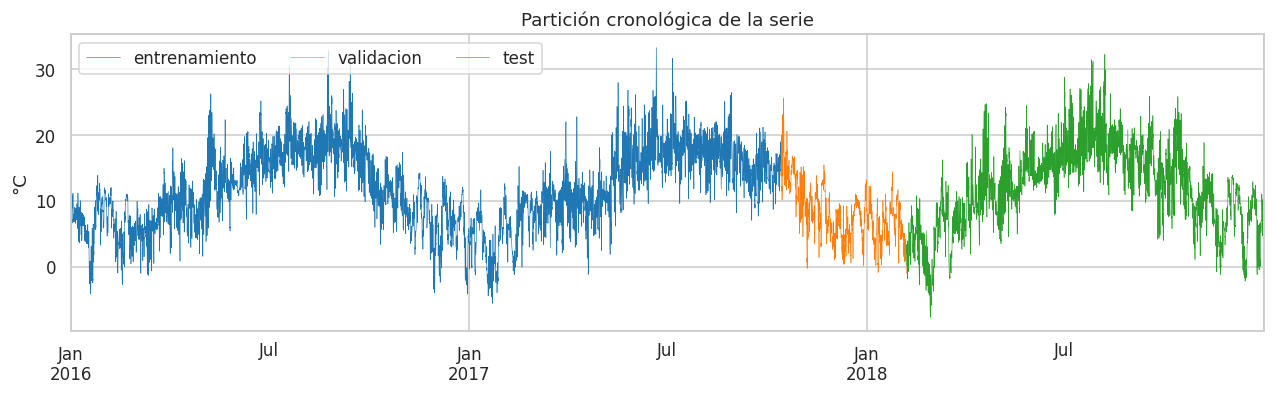

In [16]:
n = len(df)
i_test = int(n * 0.70)          # de aquí en adelante es test (30% final)
i_val = int(i_test * 0.85)      # dentro del 70%: 85% entrenamiento, 15% validación

conjuntos = {
    "entrenamiento": df.iloc[:i_val],
    "validacion":    df.iloc[i_val:i_test],
    "test":          df.iloc[i_test:],
}
for nombre, parte in conjuntos.items():
    print(f"{nombre:14s} {len(parte):6,} h  ({len(parte)/n:5.1%})   {parte.index.min()}  ->  {parte.index.max()}")

fig, ax = plt.subplots(figsize=(14, 3.5))
colores = {"entrenamiento": "tab:blue", "validacion": "tab:orange", "test": "tab:green"}
for nombre, parte in conjuntos.items():
    parte["t_c"].plot(ax=ax, lw=0.4, color=colores[nombre], label=nombre)
ax.set_ylabel("°C"); ax.set_xlabel(""); ax.legend(loc="upper left", ncol=3)
ax.set_title("Partición cronológica de la serie")
fig.savefig(RUTA_RES / "eda_particion.png", bbox_inches="tight"); plt.show()


Una consecuencia de partir así que vale la pena decir en el informe: el test va de **febrero a diciembre de 2018**, así que el modelo se evalúa sobre una primavera, un verano y un otoño que nunca vio, pero solo unas tres semanas de invierno. Es una limitación de tener solo 3 años.

### 6.4 Estadísticas para escalar

Las redes entrenan mejor con entradas centradas y con varianza parecida. Usaremos `(x - media) / desviación` por variable, pero **la media y la desviación se calculan solo con el conjunto de entrenamiento**. Si usáramos toda la serie, el modelo "sabría" algo del test aunque sea de forma indirecta. Las guardamos en la configuración.

In [17]:
stats_train = df.iloc[:i_val][FEATURES].agg(["mean", "std"]).T
stats_train.round(3)


,mean,std
t_c,11.766,5.926
td_c,8.344,5.241
hu,80.779,12.455
psl_hpa,1016.830,9.671
ff,4.808,2.857
u,1.624,3.899
v,0.665,3.555
precip,0.085,0.533
hora_sin,0.000,0.707
hora_cos,0.000,0.707


## 7. Guardar la serie preparada y la configuración de la tarea

Dos archivos:

- `estacion_62548002_preparada.csv`: la serie horaria imputada, con las variables de calendario y la bandera de imputación.
- `config_tarea.json`: la definición de la tarea (ventana, horizonte, variables, índices de corte, estadísticas de escalado). Queda como registro de lo decidido y permite reproducir la parte de modelado sin repetir el EDA.

In [18]:
columnas_guardar = FEATURES + ["t_imputada", "n_obs"]
RUTA_PREP = RUTA_DATA / f"estacion_{ESTACION}_preparada.csv"
df[columnas_guardar].round(4).to_csv(RUTA_PREP)

config = {
    "estacion": ESTACION,
    "objetivo": "t_c",
    "features": FEATURES,
    "largo_entrada_h": 72,
    "horizonte_h": 24,
    "horizonte_referencia_h": 1,
    "frecuencia": "1h",
    "i_val": int(i_val),
    "i_test": int(i_test),
    "fechas": {k: [str(v.index.min()), str(v.index.max())] for k, v in conjuntos.items()},
    "limite_interpolacion_h": LIMITE_INTERP,
    "escalado": {"media": stats_train["mean"].round(6).to_dict(), "std": stats_train["std"].round(6).to_dict()},
    "mae_persistencia_serie_completa": {str(k): round(float(mae_persistencia[k-1]), 4) for k in [1, 3, 6, 12, 24, 48]},
}
with open(RUTA_DATA / "config_tarea.json", "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2, ensure_ascii=False)

print(f"guardado {RUTA_PREP.name} ({RUTA_PREP.stat().st_size/1e6:.2f} MB)")
print("guardado config_tarea.json")
print("\nfiguras en results/punto1/:")
for p in sorted(RUTA_RES.glob("eda_*.png")):
    print("  ", p.name)


guardado estacion_62548002_preparada.csv (2.67 MB)
guardado config_tarea.json

figuras en results/punto1/:
   eda_autocorrelacion.png
   eda_ciclos_anual_diario.png
   eda_correlacion.png
   eda_dificultad_horizonte.png
   eda_distribuciones.png
   eda_huecos_temperatura.png
   eda_particion.png
   eda_serie_completa.png
   eda_zoom_dos_semanas.png


## 8. Ventanas para la red recurrente

De aquí en adelante entra Keras. Lo primero es convertir la serie en muestras (entrada de `L` horas → salida de `H` horas) como se dibujó en la sección 5. Tres detalles que importan:

- Las ventanas se construyen **dentro de cada conjunto** (entrenamiento, validación, test) por separado, así ninguna muestra mezcla horas de dos conjuntos. Se pierden las primeras `L + H` horas de cada conjunto, que es despreciable.
- Toda ventana que contenga un `NaN` (el hueco de 9 h que no imputamos) se descarta.
- Para el test guardamos además qué horas objetivo fueron imputadas, para dejarlas fuera de las métricas.

Las entradas se escalan con la media y desviación **de entrenamiento** (sección 6.4). La salida también se escala (misma media/desviación de `t_c`); al evaluar se deshace el escalado y todo se reporta en °C.

In [19]:
import time
import tensorflow as tf
from numpy.lib.stride_tricks import sliding_window_view

print("TensorFlow", tf.__version__)
gpus = tf.config.list_physical_devices("GPU")
print("GPU:", gpus[0].name if gpus else "no hay (va a ser lento)")

SEED = 42
tf.keras.utils.set_random_seed(SEED)

L_BASE, H = config["largo_entrada_h"], config["horizonte_h"]      # 72 y 24
media = np.array([config["escalado"]["media"][f] for f in FEATURES], dtype=np.float32)
desv = np.array([config["escalado"]["std"][f] for f in FEATURES], dtype=np.float32)
IDX_T = FEATURES.index("t_c")
MEDIA_T, DESV_T = float(media[IDX_T]), float(desv[IDX_T])


TensorFlow 2.20.0
GPU: /physical_device:GPU:0


In [20]:
def ventanas(parte, L, H):
    """Convierte un tramo de la serie en muestras (X: n×L×F escalado, y: n×H escalado).
    Devuelve también qué objetivos fueron imputados y la hora en que se "emite" cada pronóstico."""
    X = (parte[FEATURES].to_numpy(np.float32) - media) / desv
    y = (parte["t_c"].to_numpy(np.float32) - MEDIA_T) / DESV_T
    imputado = parte["t_imputada"].to_numpy(bool)

    n = len(parte) - L - H + 1
    Xw = sliding_window_view(X, (L, X.shape[1]))[:n, 0]     # ventana i: filas i .. i+L-1
    yw = sliding_window_view(y, H)[L:L + n]                  # objetivo i: filas i+L .. i+L+H-1
    imp_w = sliding_window_view(imputado, H)[L:L + n]
    origen = parte.index[L - 1:L - 1 + n]                    # última hora observada de cada ventana

    ok = ~np.isnan(Xw).any(axis=(1, 2)) & ~np.isnan(yw).any(axis=1)
    return {"X": np.ascontiguousarray(Xw[ok]), "y": np.ascontiguousarray(yw[ok]),
            "imputado": np.ascontiguousarray(imp_w[ok]), "origen": origen[ok]}


def preparar(L, H=H):
    return {nombre: ventanas(parte, L, H) for nombre, parte in conjuntos.items()}


datos_por_L = {L_BASE: preparar(L_BASE)}
for nombre, d in datos_por_L[L_BASE].items():
    print(f"{nombre:14s} X {str(d['X'].shape):18s} y {d['y'].shape}")


entrenamiento  X (15555, 72, 12)    y (15555, 24)
validacion     X (2563, 72, 12)     y (2563, 24)
test           X (7797, 72, 12)     y (7797, 24)


## 9. Líneas base

Antes de la primera red, tres modelos "sin aprendizaje" evaluados sobre **las mismas ventanas de test**. Si la RNN no les gana, no está aportando nada:

1. **Persistencia**: las próximas 24 h serán iguales a la última hora observada.
2. **Ayer**: cada hora será igual a la misma hora del día anterior (usa el ciclo diario, que es la estructura más fuerte de la serie).
3. **Climatología**: la temperatura media de esa hora del día y ese mes, calculada solo con entrenamiento.

Como se predicen 24 horas de una vez, el error se promedia sobre los 24 horizontes (no es solo el error "a 24 h").

In [21]:
def a_grados(y_escalado):
    return y_escalado * DESV_T + MEDIA_T


def metricas(y_real, y_pred, excluir=None):
    """MAE y RMSE en °C (promedio sobre muestras y horizontes) y MAE por horizonte. `excluir` marca objetivos imputados."""
    err = y_pred - y_real
    if excluir is not None:
        err = np.where(excluir, np.nan, err)
    return {"MAE": float(np.nanmean(np.abs(err))),
            "RMSE": float(np.sqrt(np.nanmean(err ** 2))),
            "MAE_h": np.nanmean(np.abs(err), axis=0)}


# Climatología (mes, hora) solo con entrenamiento
train_df = conjuntos["entrenamiento"]
clima = train_df.groupby([train_df.index.month, train_df.index.hour])["t_c"].mean()
clima_tabla = clima.unstack().reindex(index=range(1, 13), columns=range(24)).to_numpy()   # 12 × 24


def pred_climatologia(origen, H):
    objetivos = (origen.values[:, None] + np.arange(1, H + 1) * np.timedelta64(1, "h")).ravel()
    objetivos = pd.DatetimeIndex(objetivos)
    return clima_tabla[objetivos.month.to_numpy() - 1, objetivos.hour.to_numpy()].reshape(len(origen), H)


def lineas_base(d, L):
    y_real = a_grados(d["y"])
    t_in = a_grados(d["X"][:, :, IDX_T])                       # temperatura de la ventana de entrada, en °C
    preds = {
        "persistencia": np.repeat(t_in[:, -1:], H, axis=1),
        "ayer":         t_in[:, L - 24:L],
        "climatologia": pred_climatologia(d["origen"], H),
    }
    return y_real, preds


test_base = datos_por_L[L_BASE]["test"]
y_test_real, preds_base = lineas_base(test_base, L_BASE)
resultados_test = {}
for nombre, p in preds_base.items():
    resultados_test[nombre] = metricas(y_test_real, p, test_base["imputado"])
    print(f"{nombre:14s} MAE = {resultados_test[nombre]['MAE']:.3f} °C   RMSE = {resultados_test[nombre]['RMSE']:.3f} °C")


persistencia   MAE = 2.775 °C   RMSE = 3.792 °C
ayer           MAE = 2.126 °C   RMSE = 2.801 °C
climatologia   MAE = 2.865 °C   RMSE = 3.680 °C


> **Observaciones:** sobre las 7 797 ventanas de test: **persistencia 2,79 °C, "ayer" 2,13 °C, climatología 2,87 °C** de MAE. Como se esperaba, "ayer" es la más difícil de vencer, porque el ciclo diario es la estructura más fuerte de la serie; la climatología queda incluso por debajo de la persistencia, lo que dice que el estado actual importa más que el promedio histórico. **El número a superar es 2,13 °C.**

## 10. Red recurrente: diseño y protocolo de experimentación

### 10.1 Arquitectura

Vamos con lo más directo que funciona bien para este tipo de problema: una o dos capas recurrentes (`SimpleRNN`, `LSTM` o `GRU`) que leen las `L` horas de entrada, y una capa `Dense(24)` que produce las 24 horas de salida de una vez. Para regularizar usamos `Dropout` entre capas y, opcionalmente, penalización L2 en los pesos.

Un detalle práctico: no usamos `recurrent_dropout` porque desactiva la implementación cuDNN de LSTM/GRU en GPU y el entrenamiento se vuelve entre 5 y 10 veces más lento; con `Dropout` normal y *early stopping* se controla bien el sobreajuste.

### 10.2 Protocolo

Todas las corridas comparten lo mismo, para que la comparación sea justa:

- Optimizador Adam (lr inicial 1e-3), pérdida MSE sobre la salida escalada, lotes de 128, máximo 60 épocas.
- `EarlyStopping` sobre la pérdida de validación (paciencia 8, se restauran los mejores pesos) y `ReduceLROnPlateau` (baja el lr a la mitad tras 4 épocas sin mejora). Son los callbacks que el taller pide para reaccionar al estancamiento.
- Semilla fija. Aun así, en GPU hay algo de no determinismo; diferencias de centésimas de grado entre corridas no significan nada.
- La selección de hiperparámetros se hace **solo con validación**. El test se toca una vez, al final, con el modelo elegido.

La búsqueda se hace por etapas (una variable a la vez, partiendo de la mejor configuración de la etapa anterior). No es una grilla completa, pero es sistemática y cada decisión queda justificada con un número:

1. Tipo de celda: SimpleRNN vs LSTM vs GRU.
2. Tamaño: unidades × número de capas.
3. Regularización: dropout y L2.
4. Longitud de la ventana de entrada: 24, 48, 72, 168 h.

Cada corrida se anota en `results/punto1/experimentos_rnn.csv`. Si el notebook se vuelve a ejecutar, las corridas ya hechas se leen del archivo y no se repiten.

In [22]:
EPOCAS, LOTE, PACIENCIA = 60, 128, 8
RUTA_EXP = RUTA_RES / "experimentos_rnn.csv"
CELDAS = {"SimpleRNN": tf.keras.layers.SimpleRNN, "LSTM": tf.keras.layers.LSTM, "GRU": tf.keras.layers.GRU}


def construir_modelo(celda="GRU", unidades=64, capas=1, dropout=0.0, l2=0.0, L=L_BASE, H=H):
    reg = tf.keras.regularizers.l2(l2) if l2 > 0 else None
    modelo = tf.keras.Sequential(name=f"{celda}_{unidades}u_{capas}c")
    modelo.add(tf.keras.Input(shape=(L, len(FEATURES))))
    for i in range(capas):
        modelo.add(CELDAS[celda](unidades, return_sequences=(i < capas - 1), kernel_regularizer=reg))
        if dropout > 0:
            modelo.add(tf.keras.layers.Dropout(dropout))
    modelo.add(tf.keras.layers.Dense(H))
    modelo.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse")
    return modelo


def nombre_config(cfg):
    return f"{cfg['celda']}_u{cfg['unidades']}_c{cfg['capas']}_d{cfg['dropout']}_l2{cfg['l2']}_L{cfg['L']}"


def entrenar(cfg, verbose=0):
    """Entrena una configuración y devuelve (modelo, historia, fila de resultados)."""
    if cfg["L"] not in datos_por_L:
        datos_por_L[cfg["L"]] = preparar(cfg["L"])
    d = datos_por_L[cfg["L"]]
    tf.keras.utils.set_random_seed(SEED)
    modelo = construir_modelo(**cfg)
    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=PACIENCIA, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-5),
    ]
    t0 = time.time()
    hist = modelo.fit(d["entrenamiento"]["X"], d["entrenamiento"]["y"],
                      validation_data=(d["validacion"]["X"], d["validacion"]["y"]),
                      epochs=EPOCAS, batch_size=LOTE, callbacks=callbacks, verbose=verbose)
    segundos = time.time() - t0

    fila = dict(cfg)
    fila["id"] = nombre_config(cfg)
    for nombre in ["entrenamiento", "validacion"]:
        pred = a_grados(modelo.predict(d[nombre]["X"], batch_size=512, verbose=0))
        m = metricas(a_grados(d[nombre]["y"]), pred)
        fila[f"mae_{nombre[:5]}"] = round(m["MAE"], 4)
        fila[f"rmse_{nombre[:5]}"] = round(m["RMSE"], 4)
    fila["epocas"] = len(hist.history["loss"])
    fila["mejor_epoca"] = int(np.argmin(hist.history["val_loss"])) + 1
    fila["parametros"] = modelo.count_params()
    fila["segundos"] = round(segundos, 1)
    return modelo, hist, fila


# Registro de experimentos (se reanuda si ya existe el archivo)
tabla = pd.read_csv(RUTA_EXP) if RUTA_EXP.exists() else pd.DataFrame()
modelos, historias = {}, {}
RUTA_HIST = RUTA_RES / "historias"
RUTA_HIST.mkdir(exist_ok=True)


def cargar_historia(idc):
    """Curvas de una corrida: de memoria si se entrenó en esta sesión, si no del JSON guardado."""
    if idc in historias:
        return historias[idc].history
    ruta = RUTA_HIST / f"{idc}.json"
    return json.load(open(ruta)) if ruta.exists() else None


def correr_etapa(etapa, configs):
    global tabla
    for cfg in configs:
        idc = nombre_config(cfg)
        if len(tabla) and idc in set(tabla["id"]):
            print(f"[ya hecho] {idc}")
            continue
        modelo, hist, fila = entrenar(cfg)
        fila["etapa"] = etapa
        modelos[idc], historias[idc] = modelo, hist
        with open(RUTA_HIST / f"{idc}.json", "w") as f:
            json.dump({k: [float(x) for x in v] for k, v in hist.history.items()}, f)
        tabla = pd.concat([tabla, pd.DataFrame([fila])], ignore_index=True)
        tabla.to_csv(RUTA_EXP, index=False)
        print(f"{idc:38s} val MAE = {fila['mae_valid']:.3f} °C   train MAE = {fila['mae_entre']:.3f} °C   "
              f"({fila['epocas']} épocas, {fila['segundos']:.0f} s)")
    return tabla[tabla["etapa"] == etapa].sort_values("mae_valid")


def mejor_config(etapa):
    fila = tabla[tabla["etapa"] == etapa].sort_values("mae_valid").iloc[0]
    return {"celda": fila["celda"], "unidades": int(fila["unidades"]), "capas": int(fila["capas"]),
            "dropout": float(fila["dropout"]), "l2": float(fila["l2"]), "L": int(fila["L"])}


COLS_VER = ["id", "mae_entre", "mae_valid", "rmse_valid", "epocas", "mejor_epoca", "parametros", "segundos"]


### 10.3 Etapa 1 – Tipo de celda

Misma configuración (64 unidades, 1 capa, sin regularización, 72 h) cambiando solo la celda recurrente. Con esto respondemos la pregunta básica: ¿la compuerta de LSTM/GRU aporta frente a una RNN simple en secuencias de 72 pasos?

In [23]:
base = dict(unidades=64, capas=1, dropout=0.0, l2=0.0, L=L_BASE)
etapa1 = correr_etapa("1_celda", [dict(base, celda=c) for c in ["SimpleRNN", "LSTM", "GRU"]])
etapa1[COLS_VER]


SimpleRNN_u64_c1_d0.0_l20.0_L72        val MAE = 1.523 °C   train MAE = 1.266 °C   (22 épocas, 25 s)
LSTM_u64_c1_d0.0_l20.0_L72             val MAE = 1.615 °C   train MAE = 1.258 °C   (13 épocas, 15 s)
GRU_u64_c1_d0.0_l20.0_L72              val MAE = 1.525 °C   train MAE = 1.293 °C   (14 épocas, 14 s)


,id,mae_entre,mae_valid,rmse_valid,epocas,mejor_epoca,parametros,segundos
0,SimpleRNN_u64_c1_d0.0_l20.0_L72,1.2658,1.5230,2.0333,22,14,6488,24.6
2,GRU_u64_c1_d0.0_l20.0_L72,1.2931,1.5249,2.0536,14,6,16536,14.0
1,LSTM_u64_c1_d0.0_l20.0_L72,1.2580,1.6153,2.1528,13,5,21272,15.1


In [ ]:
# Si el notebook se reanudó desde el CSV, las curvas no están en memoria: se vuelven a entrenar
# esas tres configuraciones solo para dibujarlas (la tabla de experimentos no se toca).
for _, fila in etapa1.iterrows():
    if cargar_historia(fila["id"]) is None:
        cfg = {"celda": fila["celda"], "unidades": int(fila["unidades"]), "capas": int(fila["capas"]),
               "dropout": float(fila["dropout"]), "l2": float(fila["l2"]), "L": int(fila["L"])}
        print("recuperando curvas de", fila["id"])
        _, historias[fila["id"]], _ = entrenar(cfg)

colores_celda = {"SimpleRNN": "tab:blue", "GRU": "tab:green", "LSTM": "tab:purple"}
fig, ax = plt.subplots(figsize=(9, 3.8))
for idc in etapa1["id"]:
    h = cargar_historia(idc)
    celda = idc.split("_")[0]
    ax.plot(np.array(h["val_loss"]) ** 0.5 * DESV_T, color=colores_celda[celda], lw=2, label=f"{celda} (validación)")
    ax.plot(np.array(h["loss"]) ** 0.5 * DESV_T, color=colores_celda[celda], ls="--", alpha=0.6, label=f"{celda} (entrenamiento)")
ax.set_xlabel("época"); ax.set_ylabel("RMSE (°C)"); ax.set_title("Etapa 1: curvas de entrenamiento por tipo de celda")
ax.legend(ncol=3, fontsize=8)
fig.savefig(RUTA_RES / "rnn_etapa1_curvas.png", bbox_inches="tight"); plt.show()


> **Observaciones:** con 64 unidades, **SimpleRNN (1,523 °C) y GRU (1,525 °C) empatan** en validación; 0,002 °C es ruido de GPU. La **LSTM queda atrás (1,615 °C)**. Lo más informativo son las curvas: LSTM y GRU llegan a su mejor época muy pronto (5 y 6) y de ahí en adelante el error de validación sube mientras el de entrenamiento sigue bajando, es decir, **sobreajustan rápido**; la SimpleRNN tarda más (mejor época 14) y sus curvas van más juntas. Tiene sentido: LSTM y GRU tienen 3-4 veces más parámetros (21 k y 16,5 k frente a 6,5 k) para las mismas 15 500 muestras, y el problema, dominado por un ciclo diario muy regular que además le damos codificado como entrada, no necesita la memoria de largo plazo que aportan las compuertas. Por la regla del protocolo (menor MAE de validación) seguimos con SimpleRNN; en la sección 11.6 se verifica que la conclusión se mantiene con la configuración final.

### 10.4 Etapa 2 – Tamaño de la red

Con la mejor celda, variamos capacidad: unidades ∈ {32, 64, 128} y capas ∈ {1, 2}. Buscamos el punto donde agregar capacidad deja de mejorar validación (o empieza a empeorarla por sobreajuste).

In [25]:
cfg2 = mejor_config("1_celda")
print("partimos de:", cfg2)
etapa2 = correr_etapa("2_tamano", [dict(cfg2, unidades=u, capas=c) for u in [32, 64, 128] for c in [1, 2]])
etapa2[COLS_VER]


partimos de: {'celda': 'SimpleRNN', 'unidades': 64, 'capas': 1, 'dropout': 0.0, 'l2': 0.0, 'L': 72}
SimpleRNN_u32_c1_d0.0_l20.0_L72        val MAE = 1.454 °C   train MAE = 1.298 °C   (32 épocas, 32 s)
SimpleRNN_u32_c2_d0.0_l20.0_L72        val MAE = 1.533 °C   train MAE = 1.222 °C   (39 épocas, 64 s)
[ya hecho] SimpleRNN_u64_c1_d0.0_l20.0_L72
SimpleRNN_u64_c2_d0.0_l20.0_L72        val MAE = 1.543 °C   train MAE = 1.314 °C   (15 épocas, 29 s)
SimpleRNN_u128_c1_d0.0_l20.0_L72       val MAE = 1.618 °C   train MAE = 1.395 °C   (11 épocas, 15 s)
SimpleRNN_u128_c2_d0.0_l20.0_L72       val MAE = 1.602 °C   train MAE = 1.107 °C   (17 épocas, 34 s)


,id,mae_entre,mae_valid,rmse_valid,epocas,mejor_epoca,parametros,segundos
3,SimpleRNN_u32_c1_d0.0_l20.0_L72,1.2977,1.4543,1.9615,32,24,2232,32.5
4,SimpleRNN_u32_c2_d0.0_l20.0_L72,1.2225,1.5331,2.0471,39,31,4312,64.5
5,SimpleRNN_u64_c2_d0.0_l20.0_L72,1.3141,1.5429,2.0363,15,7,14744,29.4
7,SimpleRNN_u128_c2_d0.0_l20.0_L72,1.1069,1.6017,2.1468,17,9,54040,34.1
6,SimpleRNN_u128_c1_d0.0_l20.0_L72,1.3951,1.6177,2.1620,11,3,21144,14.7


### 10.5 Etapa 3 – Regularización

Con el mejor tamaño, probamos dropout ∈ {0, 0.2, 0.4} y L2 ∈ {0, 1e-4}. Si en la etapa anterior el modelo grande sobreajustaba, aquí debería notarse la ganancia; si no había sobreajuste, la regularización puede incluso empeorar un poco (y eso también es un resultado que vale la pena reportar).

In [26]:
cfg3 = mejor_config("2_tamano")
print("partimos de:", cfg3)
etapa3 = correr_etapa("3_regularizacion", [dict(cfg3, dropout=d, l2=l) for d in [0.0, 0.2, 0.4] for l in [0.0, 1e-4]])
etapa3[COLS_VER]


partimos de: {'celda': 'SimpleRNN', 'unidades': 32, 'capas': 1, 'dropout': 0.0, 'l2': 0.0, 'L': 72}
[ya hecho] SimpleRNN_u32_c1_d0.0_l20.0_L72
SimpleRNN_u32_c1_d0.0_l20.0001_L72     val MAE = 1.455 °C   train MAE = 1.302 °C   (31 épocas, 36 s)
SimpleRNN_u32_c1_d0.2_l20.0_L72        val MAE = 1.500 °C   train MAE = 1.358 °C   (43 épocas, 46 s)
SimpleRNN_u32_c1_d0.2_l20.0001_L72     val MAE = 1.501 °C   train MAE = 1.357 °C   (43 épocas, 44 s)
SimpleRNN_u32_c1_d0.4_l20.0_L72        val MAE = 1.521 °C   train MAE = 1.400 °C   (59 épocas, 57 s)
SimpleRNN_u32_c1_d0.4_l20.0001_L72     val MAE = 1.521 °C   train MAE = 1.401 °C   (59 épocas, 59 s)


,id,mae_entre,mae_valid,rmse_valid,epocas,mejor_epoca,parametros,segundos
8,SimpleRNN_u32_c1_d0.0_l20.0001_L72,1.3024,1.4550,1.9619,31,23,2232,35.9
9,SimpleRNN_u32_c1_d0.2_l20.0_L72,1.3576,1.5003,2.0203,43,35,2232,45.5
10,SimpleRNN_u32_c1_d0.2_l20.0001_L72,1.3574,1.5013,2.0212,43,35,2232,44.0
12,SimpleRNN_u32_c1_d0.4_l20.0001_L72,1.4006,1.5209,2.0144,59,51,2232,58.9
11,SimpleRNN_u32_c1_d0.4_l20.0_L72,1.3996,1.5211,2.0143,59,51,2232,57.2


### 10.6 Etapa 4 – Longitud de la ventana de entrada

Último hiperparámetro, y uno de los que el taller pide justificar: ¿cuánta historia necesita el modelo? Probamos 24 h (un solo ciclo diario), 48, 72 (nuestra propuesta) y 168 h (una semana).

In [27]:
cfg4 = mejor_config("3_regularizacion")
print("partimos de:", cfg4)
etapa4 = correr_etapa("4_ventana", [dict(cfg4, L=L) for L in [24, 48, 72, 168]])
etapa4[COLS_VER]


partimos de: {'celda': 'SimpleRNN', 'unidades': 32, 'capas': 1, 'dropout': 0.0, 'l2': 0.0001, 'L': 72}
SimpleRNN_u32_c1_d0.0_l20.0001_L24     val MAE = 1.481 °C   train MAE = 1.259 °C   (45 épocas, 33 s)
SimpleRNN_u32_c1_d0.0_l20.0001_L48     val MAE = 1.440 °C   train MAE = 1.228 °C   (55 épocas, 45 s)
[ya hecho] SimpleRNN_u32_c1_d0.0_l20.0001_L72
SimpleRNN_u32_c1_d0.0_l20.0001_L168    val MAE = 1.436 °C   train MAE = 1.260 °C   (49 épocas, 82 s)


,id,mae_entre,mae_valid,rmse_valid,epocas,mejor_epoca,parametros,segundos
15,SimpleRNN_u32_c1_d0.0_l20.0001_L168,1.2601,1.4358,1.9449,49,41,2232,81.6
14,SimpleRNN_u32_c1_d0.0_l20.0001_L48,1.2276,1.4398,1.9446,55,47,2232,45.0
13,SimpleRNN_u32_c1_d0.0_l20.0001_L24,1.2586,1.4806,1.9991,45,37,2232,33.2


In [ ]:
# Resumen de toda la búsqueda
tabla = tabla.sort_values(["etapa", "mae_valid"])
busqueda = tabla[tabla["etapa"].str[0].isin(list("1234"))]      # la verificación de 11.6 no participa en la selección
mejor = busqueda.sort_values("mae_valid").iloc[0]
print("Mejor configuración por validación:", mejor["id"], f"-> val MAE {mejor['mae_valid']:.3f} °C")

fig, ax = plt.subplots(figsize=(12, 4))
colores_etapa = {"1_celda": "tab:blue", "2_tamano": "tab:orange", "3_regularizacion": "tab:green", "4_ventana": "tab:red"}
ax.bar(busqueda["id"], busqueda["mae_valid"], color=busqueda["etapa"].map(colores_etapa).tolist())
ax.axhline(resultados_test["ayer"]["MAE"], color="gray", ls="--", lw=1, label='línea base "ayer" (test)')
ax.set_ylabel("MAE validación (°C)"); ax.set_title("Búsqueda de hiperparámetros por etapas")
ax.tick_params(axis="x", rotation=90, labelsize=7); ax.legend()
fig.savefig(RUTA_RES / "rnn_busqueda_hiperparametros.png", bbox_inches="tight"); plt.show()
busqueda[["etapa"] + COLS_VER]


> **Observaciones sobre la búsqueda (16 corridas, 11 minutos de GPU en total):**
>
> - **Tamaño (etapa 2):** el modelo más pequeño ganó. 32 unidades × 1 capa dio 1,454 °C frente a 1,523 (64) y 1,618 (128). Apilar dos capas no ayudó en ningún tamaño (1,533-1,602). El caso extremo es 128 × 2: es el que mejor ajusta entrenamiento (1,107 °C) y uno de los peores en validación (1,602 °C), sobreajuste de manual. Con 15 500 muestras y una señal tan regular, más capacidad solo sirve para memorizar.
> - **Regularización (etapa 3):** no aportó. L2 = 1e-4 dio lo mismo que nada (1,455 vs 1,454); el dropout **empeoró** (0,2 → 1,500; 0,4 → 1,521) y además alargó el entrenamiento a 43-59 épocas. Es coherente: el modelo de 32 unidades casi no sobreajusta (la brecha train-val es de ~0,15 °C), así que no había nada que regularizar. Se mantuvo L2 = 1e-4 por ser el mejor por milésimas, aunque en la práctica equivale a no regularizar.
> - **Ventana (etapa 4):** 168 h (1,436) ≈ 48 h (1,440) < 72 h (1,455) < 24 h (1,481). Solo 24 h es claramente peor: con un único ciclo diario el modelo no ve la tendencia. Entre 48 y 168 h la diferencia es de centésimas, pero 168 h cuesta casi el doble de tiempo (82 s frente a 45 s). Por el criterio se eligió 168 h; 48 h sería la opción "económica" con prácticamente el mismo desempeño.
> - **Lo que no funcionó:** más unidades, más capas, dropout y la celda LSTM. **Lo que sí:** un modelo pequeño (2 232 parámetros), sin dropout, con al menos dos días de historia.
> - Todas las configuraciones, incluso la peor, quedaron muy por debajo de la línea base "ayer" (2,13 °C, línea punteada de la figura).

## 11. Evaluación final en test

Ahora sí, una sola vez, el modelo elegido contra el 30 % final de la serie (febrero–diciembre 2018), que no se usó para nada hasta este momento. Comparamos contra las tres líneas base sobre las mismas ventanas y excluyendo las horas imputadas.

In [ ]:
cfg_final = {"celda": mejor["celda"], "unidades": int(mejor["unidades"]), "capas": int(mejor["capas"]),
             "dropout": float(mejor["dropout"]), "l2": float(mejor["l2"]), "L": int(mejor["L"])}
id_final = nombre_config(cfg_final)

RUTA_MODELO = RUTA_RES / "modelo_rnn_final.keras"
RUTA_METRICAS = RUTA_RES / "metricas_test.json"
if id_final not in modelos:
    # Si el notebook se reanudó, se carga el modelo guardado (siempre que sea de la misma configuración);
    # así los números del test no cambian entre ejecuciones. Si no existe, se reentrena.
    guardado = json.load(open(RUTA_METRICAS)).get("modelo_final", {}) if RUTA_METRICAS.exists() else {}
    if RUTA_MODELO.exists() and all(str(guardado.get(k)) == str(v) for k, v in cfg_final.items()):
        print("cargando el modelo final guardado")
        modelos[id_final] = tf.keras.models.load_model(RUTA_MODELO)
    else:
        print("reentrenando el modelo elegido...")
        modelos[id_final], historias[id_final], _ = entrenar(cfg_final)
modelo_final = modelos[id_final]
L_FIN = cfg_final["L"]

d_test = datos_por_L[L_FIN]["test"]
y_test_real, preds_base = lineas_base(d_test, L_FIN)
pred_rnn = a_grados(modelo_final.predict(d_test["X"], batch_size=512, verbose=0))

resultados_test = {n: metricas(y_test_real, p, d_test["imputado"]) for n, p in preds_base.items()}
resultados_test["RNN"] = metricas(y_test_real, pred_rnn, d_test["imputado"])

comparacion = pd.DataFrame({n: {"MAE (°C)": r["MAE"], "RMSE (°C)": r["RMSE"]} for n, r in resultados_test.items()}).T
comparacion["mejora vs ayer"] = (1 - comparacion["MAE (°C)"] / comparacion.loc["ayer", "MAE (°C)"]).map("{:+.1%}".format)
print(f"Modelo final: {id_final}  ({modelo_final.count_params():,} parámetros)")
print(f"Ventanas de test: {len(d_test['y']):,}")
comparacion.round(3)


In [30]:
modelo_final.save(RUTA_RES / "modelo_rnn_final.keras")
modelo_final.summary()


Model: "SimpleRNN_32u_1c"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_16 (SimpleRNN)       │ (None, 32)             │         1,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 24)             │           792 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,698 (26.17 KB)

 Trainable params: 2,232 (8.72 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4,466 (17.45 KB)

### 11.1 Error por horizonte

La pregunta natural: ¿el modelo es bueno a 1 h y se degrada a 24 h, o mantiene el error parejo? Y contra las líneas base, ¿en qué horizontes gana más?

> **Resultado en test:** **RNN MAE 1,602 °C / RMSE 2,142 °C**, frente a 2,128 de "ayer", 2,785 de persistencia y 2,871 de climatología. Es una **mejora del 24,7 %** sobre la mejor línea base, con un modelo de 2 232 parámetros que entrena en poco más de un minuto.

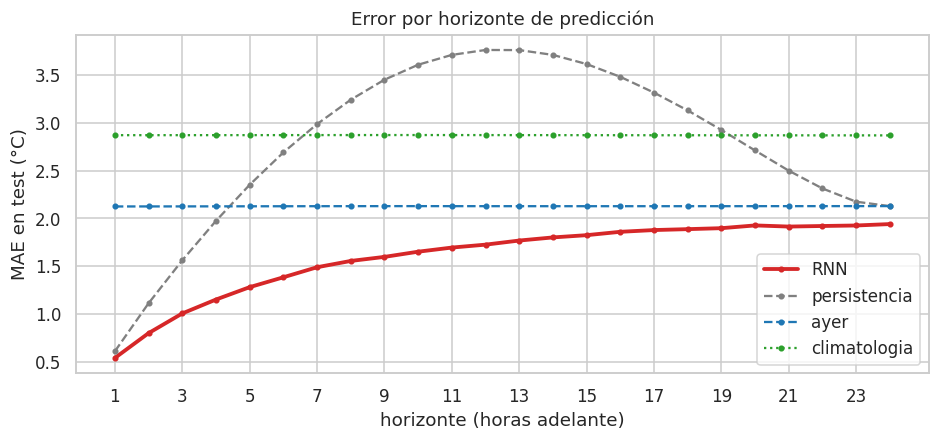

MAE de la RNN a 1 h: 0.541 °C   6 h: 1.385 °C   12 h: 1.726 °C   24 h: 1.941 °C


In [31]:
fig, ax = plt.subplots(figsize=(10, 4))
hs = np.arange(1, H + 1)
for nombre, estilo in [("RNN", dict(lw=2.5, color="tab:red")), ("persistencia", dict(ls="--", color="gray")),
                       ("ayer", dict(ls="--", color="tab:blue")), ("climatologia", dict(ls=":", color="tab:green"))]:
    ax.plot(hs, resultados_test[nombre]["MAE_h"], marker="o", ms=3, label=nombre, **estilo)
ax.set_xlabel("horizonte (horas adelante)"); ax.set_ylabel("MAE en test (°C)"); ax.set_xticks(hs[::2])
ax.set_title("Error por horizonte de predicción"); ax.legend()
fig.savefig(RUTA_RES / "rnn_test_error_por_horizonte.png", bbox_inches="tight"); plt.show()

print("MAE de la RNN a 1 h: %.3f °C   6 h: %.3f °C   12 h: %.3f °C   24 h: %.3f °C" % tuple(resultados_test["RNN"]["MAE_h"][[0, 5, 11, 23]]))


### 11.2 ¿Cuándo se equivoca más? Error por mes y por hora de emisión

Agrupamos el error de cada ventana según el mes y según la hora en que se "emitió" el pronóstico. Esto dice, por ejemplo, si el modelo sufre en verano (más amplitud diaria) o si los pronósticos emitidos de madrugada son mejores que los de mediodía.

> **Observaciones sobre el error por horizonte (figura anterior):** el error crece de forma suave y monótona, de **0,54 °C a 1 h** a 1,39 (6 h), 1,73 (12 h) y **1,94 °C a 24 h**. La RNN queda por debajo de todas las líneas base en los 24 horizontes. Donde más gana es en el tramo de 4 a 20 h, justo donde la persistencia se dispara (hasta 3,8 °C a 12 h); a 24 h la ventaja sobre "ayer" se reduce (1,94 frente a 2,13), porque ahí el ciclo diario ya le da a "ayer" casi toda la información. A 1 h la RNN también gana a la persistencia (0,54 frente a 0,61).

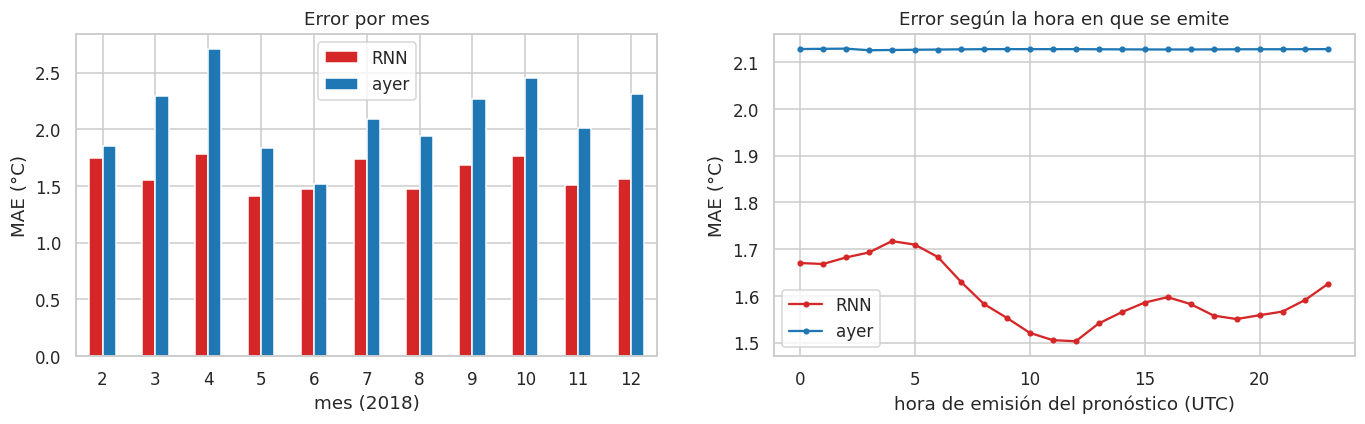

In [32]:
err_abs = np.abs(pred_rnn - y_test_real)
err_abs = np.where(d_test["imputado"], np.nan, err_abs)
err_ventana = pd.Series(np.nanmean(err_abs, axis=1), index=d_test["origen"])
err_ayer = pd.Series(np.nanmean(np.where(d_test["imputado"], np.nan, np.abs(preds_base["ayer"] - y_test_real)), axis=1), index=d_test["origen"])

fig, axes = plt.subplots(1, 2, figsize=(15, 3.8))
pd.DataFrame({"RNN": err_ventana.groupby(err_ventana.index.month).mean(),
              "ayer": err_ayer.groupby(err_ayer.index.month).mean()}).plot.bar(ax=axes[0], color=["tab:red", "tab:blue"])
axes[0].set_xlabel("mes (2018)"); axes[0].set_ylabel("MAE (°C)"); axes[0].set_title("Error por mes"); axes[0].tick_params(axis="x", rotation=0)

pd.DataFrame({"RNN": err_ventana.groupby(err_ventana.index.hour).mean(),
              "ayer": err_ayer.groupby(err_ayer.index.hour).mean()}).plot(ax=axes[1], marker="o", ms=3, color=["tab:red", "tab:blue"])
axes[1].set_xlabel("hora de emisión del pronóstico (UTC)"); axes[1].set_ylabel("MAE (°C)"); axes[1].set_title("Error según la hora en que se emite")
fig.savefig(RUTA_RES / "rnn_test_error_mes_hora.png", bbox_inches="tight"); plt.show()


### 11.3 Ejemplos concretos

Los números resumen, pero mirar pronósticos individuales es lo que de verdad enseña. Tomamos pronósticos emitidos a medianoche y mostramos el mejor, uno típico (mediana) y el peor día de test: las últimas 48 h observadas, las 24 h reales y lo que dijo la red.

> **Observaciones sobre mes y hora de emisión:** por mes, la RNN gana a "ayer" en todos, y la ventaja es mayor donde "ayer" falla más: **abril** (1,78 frente a 2,71), marzo, septiembre y octubre, meses de transición con cambios bruscos de un día a otro. Los meses con menor error son **mayo y junio** (1,41 y 1,47 °C); los peores, abril, febrero, julio y octubre (~1,75). En junio ambos modelos empatan (1,47 vs 1,51): días muy parecidos entre sí. Por hora de emisión hay un patrón claro: los pronósticos emitidos **de madrugada (3-5 UTC) son los peores (1,72 °C)** y los emitidos hacia el **mediodía (11-12 UTC) los mejores (1,50 °C)**. Es lógico: a mediodía el modelo ya vio cómo empezó el día y cuánto subió la temperatura; a las 4 de la mañana tiene que "adivinar" el pico de la tarde con la información de ayer.

In [ ]:
import matplotlib.dates as mdates

medianoche = np.where(d_test["origen"].hour == 0)[0]
orden = medianoche[np.argsort(err_ventana.iloc[medianoche].values)]
casos = {"mejor día": orden[0], "día típico (mediana)": orden[len(orden) // 2], "peor día": orden[-1]}

fig, axes = plt.subplots(1, 3, figsize=(16, 3.8), sharey=False)
for ax, (titulo, i) in zip(axes, casos.items()):
    origen = d_test["origen"][i]
    pasado = pd.Series(a_grados(d_test["X"][i, -48:, IDX_T]), index=origen - pd.to_timedelta(np.arange(47, -1, -1), "h"))
    futuro_idx = origen + pd.to_timedelta(np.arange(1, H + 1), "h")
    ax.plot(pasado.index, pasado.values, color="black", lw=1, label="observado (entrada)")
    ax.plot(futuro_idx, y_test_real[i], color="black", lw=1, ls="--", label="real")
    ax.plot(futuro_idx, pred_rnn[i], color="tab:red", lw=2, label="RNN")
    ax.plot(futuro_idx, preds_base["ayer"][i], color="tab:blue", lw=1, alpha=0.6, label="ayer")
    ax.axvline(origen, color="gray", lw=0.8)
    ax.set_title(f"{titulo}: {origen.date()}  (MAE {err_ventana.iloc[i]:.2f} °C)"); ax.set_xlabel(""); ax.set_ylabel("°C")
    ax.xaxis.set_major_locator(mdates.HourLocator(byhour=[0, 12]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b\n%H:%M"))
    ax.tick_params(axis="x", labelsize=8)
axes[0].legend(fontsize=8)
fig.savefig(RUTA_RES / "rnn_test_ejemplos.png", bbox_inches="tight"); plt.show()


### 11.4 Distribución del error y sesgo

Por último: ¿el error es simétrico o el modelo tiende a quedarse corto (por ejemplo, subestimar los picos de la tarde)? Un histograma del error firmado a distintos horizontes lo muestra.

> **Observaciones sobre los ejemplos:** el **mejor día** (17 de mayo, MAE 0,20 °C) es un día "de libro": ciclo diario limpio y la red lo reproduce casi exacto, incluso mejor que "ayer". El **día típico** (21 de julio, 1,51 °C) muestra la limitación más frecuente: la red sigue bien la forma pero **suaviza el pico de la tarde** (predice ~21 °C cuando llegó a ~23,7 °C); tiende a quedarse corta en los extremos. El **peor día** (17 de marzo, 6,94 °C) es la entrada de un frente frío: la temperatura cae de 6 °C a -1 °C durante el día y ni la RNN ni "ayer" lo ven venir, porque nada en las 168 h anteriores de esta estación lo anuncia. Ese tipo de evento solo se anticipa con información espacial (estaciones vecinas, modelo numérico), que no está en las entradas.

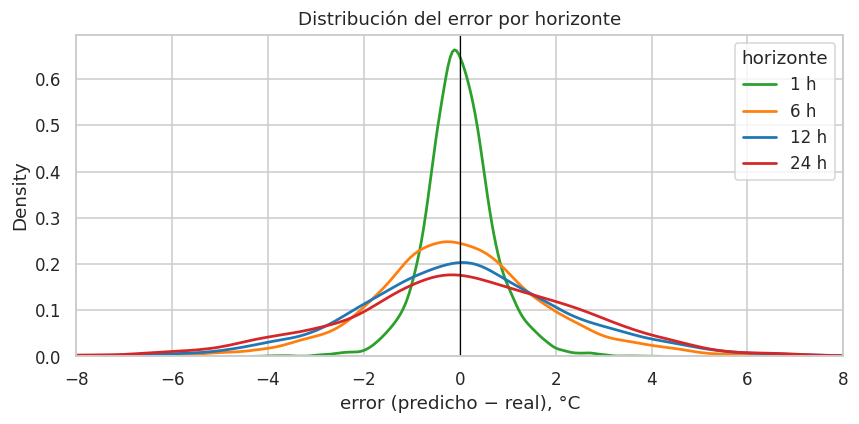

Sesgo medio: +0.107 °C   |   el 95 % de los errores absolutos está por debajo de 4.44 °C


In [34]:
err_firmado = np.where(d_test["imputado"], np.nan, pred_rnn - y_test_real)
fig, ax = plt.subplots(figsize=(9, 3.8))
for k, color in [(1, "tab:green"), (6, "tab:orange"), (12, "tab:blue"), (24, "tab:red")]:
    sns.kdeplot(err_firmado[:, k - 1][~np.isnan(err_firmado[:, k - 1])], ax=ax, color=color, label=f"{k} h", lw=1.8)
ax.axvline(0, color="black", lw=0.8); ax.set_xlim(-8, 8)
ax.set_xlabel("error (predicho − real), °C"); ax.set_title("Distribución del error por horizonte"); ax.legend(title="horizonte")
fig.savefig(RUTA_RES / "rnn_test_distribucion_error.png", bbox_inches="tight"); plt.show()

sesgo = np.nanmean(err_firmado); p95 = np.nanpercentile(np.abs(err_firmado), 95)
print(f"Sesgo medio: {sesgo:+.3f} °C   |   el 95 % de los errores absolutos está por debajo de {p95:.2f} °C")


### 11.5 Referencia: horizonte de 1 hora

Para tener el punto de comparación "fácil" que mencionamos en la sección 5: la misma arquitectura elegida, pero prediciendo solo la próxima hora. Aquí la persistencia ya es muy buena (0.5-0.6 °C), así que el margen de mejora es pequeño; sirve para mostrar que el problema interesante es el de 24 h.

> **Observaciones sobre la distribución del error:** las curvas están centradas casi en cero: el **sesgo medio es de +0,11 °C** (leve sobreestimación, despreciable frente al MAE). A 1 h el error es muy concentrado (casi todo entre -1 y +1 °C); a 6, 12 y 24 h la campana se ensancha y aparecen colas largas de ±4 a ±6 °C, que corresponden a los días de cambio de masa de aire como el del ejemplo. El **95 % de los errores absolutos está por debajo de 4,4 °C**. Las colas son simétricas, así que el modelo no falla sistemáticamente hacia un lado; falla cuando pasa algo que no está en su historia.

In [ ]:
datos_h1 = {nombre: ventanas(parte, cfg_final["L"], 1) for nombre, parte in conjuntos.items()}
RUTA_MODELO_H1 = RUTA_RES / "modelo_rnn_horizonte_1h.keras"
if RUTA_MODELO_H1.exists():
    modelo_h1 = tf.keras.models.load_model(RUTA_MODELO_H1)
else:
    tf.keras.utils.set_random_seed(SEED)
    modelo_h1 = construir_modelo(celda=cfg_final["celda"], unidades=cfg_final["unidades"], capas=cfg_final["capas"],
                                 dropout=cfg_final["dropout"], l2=cfg_final["l2"], L=cfg_final["L"], H=1)
    modelo_h1.fit(datos_h1["entrenamiento"]["X"], datos_h1["entrenamiento"]["y"],
                  validation_data=(datos_h1["validacion"]["X"], datos_h1["validacion"]["y"]),
                  epochs=EPOCAS, batch_size=LOTE, verbose=0,
                  callbacks=[tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=PACIENCIA, restore_best_weights=True),
                             tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-5)])
    modelo_h1.save(RUTA_MODELO_H1)

d1 = datos_h1["test"]
y1_real = a_grados(d1["y"])
pred1_rnn = a_grados(modelo_h1.predict(d1["X"], batch_size=512, verbose=0))
pred1_pers = a_grados(d1["X"][:, -1:, IDX_T])
m1_rnn, m1_pers = metricas(y1_real, pred1_rnn, d1["imputado"]), metricas(y1_real, pred1_pers, d1["imputado"])
print(f"Horizonte 1 h en test:  RNN MAE = {m1_rnn['MAE']:.3f} °C   |   persistencia MAE = {m1_pers['MAE']:.3f} °C")


### 11.6 Verificación: ¿la elección de la celda dependía del tamaño?

En la etapa 1 comparamos las celdas con 64 unidades, y de ahí en adelante toda la búsqueda siguió con SimpleRNN. Queda la duda razonable de si una GRU o LSTM **pequeña** (32 unidades, 168 h, la configuración final) habría hecho lo mismo o mejor. Lo comprobamos aquí, solo en validación y **después** de haber evaluado el test, para que no cuente como selección: es un chequeo de robustez de la conclusión, no una etapa más de búsqueda.

In [ ]:
verificacion = correr_etapa("5_verificacion", [dict(cfg_final, celda=c) for c in ["SimpleRNN", "GRU", "LSTM"]])
verificacion[COLS_VER]


> **Observaciones (completar después de correr):** anotar el MAE de validación de las tres celdas con la configuración final y decir si se mantiene el orden de la etapa 1 (SimpleRNN ≈ GRU < LSTM) o cambia. Si GRU/LSTM pequeñas igualan a la SimpleRNN, la conclusión del informe es que "con esta tarea la celda importa poco y el tamaño importa mucho"; si quedan por detrás, se refuerza la elección.

## 12. Resultados guardados y cierre

Dejamos en `results/punto1/` todo lo que necesita el informe: la tabla de experimentos, las métricas de test en JSON, el modelo final y las figuras.

In [36]:
resumen_final = {
    "estacion": ESTACION,
    "tarea": {"entrada_h": int(L_FIN), "horizonte_h": int(H), "features": FEATURES},
    "modelo_final": cfg_final | {"parametros": int(modelo_final.count_params())},
    "test": {n: {"MAE": round(r["MAE"], 4), "RMSE": round(r["RMSE"], 4),
                 "MAE_por_horizonte": [round(float(x), 4) for x in r["MAE_h"]]} for n, r in resultados_test.items()},
    "test_horizonte_1h": {"RNN_MAE": round(m1_rnn["MAE"], 4), "persistencia_MAE": round(m1_pers["MAE"], 4)},
    "sesgo_medio_C": round(float(sesgo), 4),
    "n_ventanas_test": int(len(d_test["y"])),
    "tensorflow": tf.__version__,
    "gpu": gpus[0].name if gpus else None,
}
with open(RUTA_RES / "metricas_test.json", "w", encoding="utf-8") as f:
    json.dump(resumen_final, f, indent=2, ensure_ascii=False)

print("archivos generados en results/punto1/:")
for p in sorted(RUTA_RES.iterdir()):
    if p.name.startswith(("rnn_", "experimentos", "metricas", "modelo")):
        print("  ", p.name)


archivos generados en results/punto1/:
   experimentos_rnn.csv
   metricas_test.json
   modelo_rnn_final.keras
   rnn_busqueda_hiperparametros.png
   rnn_etapa1_curvas.png
   rnn_test_distribucion_error.png
   rnn_test_ejemplos.png
   rnn_test_error_mes_hora.png
   rnn_test_error_por_horizonte.png


## 13. Qué nos llevamos para el informe

**Diseño experimental**
- Estación 62548002 (Calais, costera, 3 m s. n. m.), 3 años completos, 0,09 % de faltantes en temperatura, las 7 variables disponibles incluida presión. Elegida entre 46 candidatas del notebook `00` por ser la de mejor calidad de datos.
- Serie horaria (26 304 registros) a partir de las observaciones cada 6 min. Partición cronológica 59,5 / 10,5 / 30 % (entrenamiento hasta oct-2017, validación hasta feb-2018, **test = febrero–diciembre 2018**). Escalado ajustado solo con entrenamiento; ventanas que no cruzan conjuntos; solo 15 h imputadas (huecos ≤ 6 h) y excluidas de las métricas.
- Tarea: **entrada 168 h × 12 variables → salida 24 h de temperatura** (multi-salida, una sola pasada). La propuesta inicial era 72 h; la etapa 4 mostró que 48-168 h son equivalentes y 24 h es peor. Justificada con la autocorrelación (0,90 a 24 h, 0,80 a 72 h, 0,74 a 168 h) y la curva de dificultad por horizonte.

**Experimentación** (16 corridas, una variable a la vez, decisión por MAE de validación)
- Celda: **SimpleRNN 1,523 ≈ GRU 1,525 < LSTM 1,615 °C**. Las celdas con compuertas sobreajustan en 5-6 épocas; la simple es suficiente para una dinámica dominada por el ciclo diario.
- Tamaño: **32 unidades × 1 capa** (1,454). Más unidades o más capas empeoraron; 128 × 2 es el ejemplo claro de sobreajuste (train 1,11 / val 1,60).
- Regularización: **ninguna necesaria**. L2 1e-4 neutro; dropout 0,2 y 0,4 empeoraron (1,50 y 1,52) y alargaron el entrenamiento.
- Ventana: **168 h (1,436)**, prácticamente igual a 48 h (1,440); 24 h claramente peor (1,481).
- Lo que no funcionó: capacidad extra, dropout, LSTM. Early stopping actuó en todas las corridas (mejor época entre 3 y 51; el modelo final en la 41 de 49).

**Resultados en test** (7 701 ventanas)
- **RNN: MAE 1,602 °C, RMSE 2,142 °C.** Líneas base: persistencia 2,785, **"ayer" 2,128**, climatología 2,871. **Mejora del 24,7 %** sobre la mejor línea base.
- Por horizonte: de 0,54 °C (1 h) a 1,94 °C (24 h), siempre por debajo de las tres líneas base; la mayor ventaja está entre 4 y 20 h.
- Peores meses: abril, febrero, julio, octubre (~1,75 °C); mejores: mayo-junio (~1,45). Pronósticos emitidos de madrugada (1,72) peores que los del mediodía (1,50).
- Sesgo +0,11 °C; el 95 % de los errores < 4,4 °C. Tiende a suavizar los picos de la tarde. Los errores grandes (hasta 7 °C) son cambios de masa de aire que no se anuncian en la historia local.
- Horizonte 1 h como referencia: RNN 0,41 vs persistencia 0,61 °C (mejora del 32 %, pero sobre un error ya pequeño).

**Lecciones aprendidas**
- Las líneas base valen oro: sin "ayer" (2,13 °C) uno podría creer que 1,6 °C es poco o mucho sin saberlo. La ganancia real de la RNN se mide contra ella, no contra la persistencia.
- Más grande no es mejor: el modelo ganador tiene 2 232 parámetros. Con series cortas y regulares, la capacidad sobrante se convierte en sobreajuste, y el early stopping lo delata en pocas épocas.
- La ingeniería de entradas hizo parte del trabajo de las compuertas: al darle la hora y el día en seno/coseno, la red no necesita "descubrir" el ciclo diario por sí sola, y una celda simple alcanza.
- La GPU con cuDNN hizo viable la búsqueda: 16 configuraciones en 11 minutos; sin GPU habría sido una tarde entera y probablemente habríamos probado menos.
- El límite del modelo no está en la arquitectura sino en la información: los peores días son frentes que una sola estación no puede anticipar.

**Limitaciones y trabajo futuro**
- Test con solo tres semanas de invierno; una sola estación; una sola semilla por configuración (las diferencias de centésimas no son significativas). Se podría repetir con 3-5 semillas para poner barras de error en la tabla de experimentos.
- No se probaron modelos autorregresivos, atención, ni convoluciones 1D. La mejora más prometedora es agregar estaciones vecinas o el pronóstico numérico (AROME) que también publica MeteoNet, para anticipar cambios de masa de aire.
